# **Why Catastrophic Forgetting Happens**

## **1. Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt

## **2. Device Configuration**

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## **3. Data Transformation**

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

## **4. Load MNIST Dataset**

In [4]:
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 475kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]


## **5. Split Dataset into Two Tasks**

In [5]:
def get_indices(dataset, classes):
  indices = []
  for i, (_, label) in enumerate(dataset):
    if label in classes:
      indices.append(i)
  return indices

task1_classes = [0, 1, 2, 3, 4]
task2_classes = [5, 6, 7, 8, 9]

task1_train_idx = get_indices(train_dataset, task1_classes)
task2_train_idx = get_indices(train_dataset, task2_classes)

task1_test_idx = get_indices(test_dataset, task1_classes)
task2_test_idx = get_indices(test_dataset, task2_classes)

task1_train = Subset(train_dataset, task1_train_idx)
task2_train = Subset(train_dataset, task2_train_idx)

task1_test = Subset(test_dataset, task1_test_idx)
task2_test = Subset(test_dataset, task2_test_idx)

## **6. DataLoaders**

In [6]:
task1_loader = DataLoader(task1_train, batch_size=64, shuffle=True)
task2_loader = DataLoader(task2_train, batch_size=64, shuffle=True)

task1_test_loader = DataLoader(task1_test, batch_size=64, shuffle=False)
task2_test_loader = DataLoader(task2_test, batch_size=64, shuffle=False)

## **7. Simple CNN Model**

In [16]:
class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()

    self.features = nn.Sequential(
        nn.Conv2d(1, 32, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64 * 7 * 7, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )

  def forward(self, x):
    return self.classifier(self.features(x))

model = SimpleCNN().to(device)

## **8. Loss & Optimizer**

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## **9. Traning Function**

In [18]:
def train(loader, epochs=3):
  model.train()
  for epoch in range(epochs):
    running_loss = 0
    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)

      loss = criterion(outputs, labels)
      loss.backward()

      optimizer.step()

      running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(loader):.4f}")

## **10. Evaluation Function**

In [19]:
def evaluate(loader):
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = outputs.max(1)

      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()

  acc = 100 * correct / total
  return acc

## **11. Train on Task 1 (0-4)**

In [20]:
train(task1_loader, epochs=3)
task1_acc_before = evaluate(task1_test_loader)
print("Task 1 Accuracy (after Task 1 training):", task1_acc_before)

Epoch 1, Loss: 0.1268
Epoch 2, Loss: 0.0269
Epoch 3, Loss: 0.0184
Task 1 Accuracy (after Task 1 training): 99.51352403191282


## **12. Train on Task 2 (5-9)**

In [21]:
train(task2_loader, epochs=3)
task2_acc = evaluate(task2_test_loader)
task1_acc_after = evaluate(task1_test_loader)

Epoch 1, Loss: 0.2112
Epoch 2, Loss: 0.0326
Epoch 3, Loss: 0.0238


## **13. Results Comparison**

In [22]:
print("Task 1 Accuracy (before task 2): ", task1_acc_before)
print("Task 2 Accuracy: ", task2_acc)
print("Task 1 Accuracy (after task 2):", task1_acc_after)

Task 1 Accuracy (before task 2):  99.51352403191282
Task 2 Accuracy:  99.01254885825962
Task 1 Accuracy (after task 2): 0.0


## **14. Visualization of Forgetting**

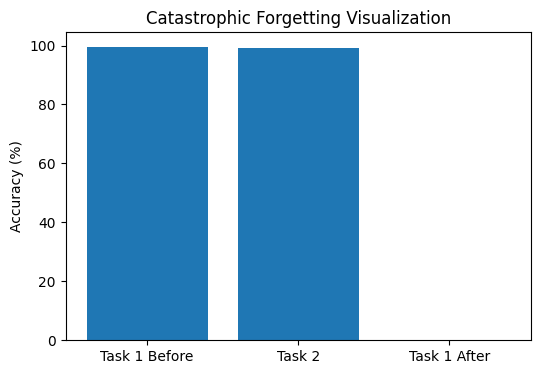

In [31]:
labels = ["Task 1 Before", "Task 2", "Task 1 After"]
accs = [task1_acc_before, task2_acc, task1_acc_after]

plt.figure(figsize=(6, 4))
plt.bar(labels, accs)
plt.ylabel("Accuracy (%)")
plt.title("Catastrophic Forgetting Visualization")
plt.show()
